# 👟 05. Daily Activity & Step Volume Distribution
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook investigates daily step volume, intensity minutes (very active vs sedentary), and acute 7-day step surges (`steps_change_7d_vs_30d`) across athlete cohorts.

---

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'

# Resolve paths
data_dir = '../data' if os.path.exists('../data') else 'data'
outputs_dir = '../outputs' if os.path.exists('../outputs') else 'outputs'

# Load daily activity records and engineered features
act_df = pd.read_csv(os.path.join(data_dir, 'dailyActivity_merged.csv'))
feats_path = os.path.join(outputs_dir, 'features.parquet')
feats_df = pd.read_parquet(feats_path) if os.path.exists(feats_path) else None

print(f"Total Daily Activity Records: {len(act_df):,}")
if feats_df is not None:
    print(f"Athletes with Engineered Activity Features: {len(feats_df):,}")

Total Daily Activity Records: 180,000
Athletes with Engineered Activity Features: 3,000


## 1. Daily Activity Summary Statistics

In [2]:
# Raw Daily Activity stats
raw_act_stats = act_df[['TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'SedentaryMinutes', 'Calories']].describe().T
display(raw_act_stats)

# Engineered 30d activity stats by injury status
if feats_df is not None:
    act_cols = ['avg_steps_30d', 'avg_steps_7d', 'steps_change_7d_vs_30d', 'avg_active_minutes_30d', 'avg_sedentary_minutes_30d']
    act_by_inj = feats_df.groupby('injured_in_risk_window')[act_cols].describe().T
    display(act_by_inj)

,count,mean,std,min,25%,50%,75%,max
TotalSteps,180000.0,8490.310633,4413.748686,200.00,5959.00,8181.00,10213.00,46780.00
TotalDistance,180000.0,6.367740,3.310314,0.15,4.47,6.14,7.66,35.08
VeryActiveMinutes,180000.0,23.534739,11.213859,0.00,17.00,23.00,27.00,104.00
SedentaryMinutes,180000.0,1200.000000,0.000000,1200.00,1200.00,1200.00,1200.00,1200.00
Calories,180000.0,2123.580194,254.247408,1610.00,1979.00,2118.00,2209.00,4121.00


injured_in_risk_window                      0             1
avg_steps_30d             count   1950.000000   1050.000000
                          mean    8074.203214   9088.757175
                          std     1751.556857   2521.082615
                          min     3425.433333   3369.100000
                          25%     6888.866667   7359.141667
                          50%     8087.483333   8850.733333
                          75%     9281.958333  10426.983333
                          max    14235.766667  20166.033333
avg_steps_7d              count   1950.000000   1050.000000
                          mean    8020.786300  11360.267755
                          std     1786.322972   5161.486254
                          min     3240.285714   3175.571429
                          25%     6779.142857   7750.964286
                          50%     8003.857143   9717.928571
                          75%     9294.000000  13789.678571
                          max    14902.571429  34987.857143
steps_change_7d_vs_30d    count   1950.000000   1050.000000
                          mean       0.993509      1.211426
                          std        0.052582      0.258517
                          min        0.816295      0.876969
                          25%        0.963327      0.992895
                          50%        0.992115      1.064612
                          75%        1.021123      1.484598
                          max        1.344793      1.758382
avg_active_minutes_30d    count   1950.000000   1050.000000
                          mean     239.996359    240.001937
                          std        0.089757      0.087652
                          min      239.733333    239.733333
                          25%      239.933333    239.933333
                          50%      240.000000    240.000000
                          75%      240.066667    240.066667
                          max      240.333333    240.300000
avg_sedentary_minutes_30d count   1950.000000   1050.000000
                          mean    1200.000000   1200.000000
                          std        0.000000      0.000000
                          min     1200.000000   1200.000000
                          25%     1200.000000   1200.000000
                          50%     1200.000000   1200.000000
                          75%     1200.000000   1200.000000
                          max     1200.000000   1200.000000

## 2. Daily Steps Distribution

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2531/2604840566.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='avg_steps_30d',
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2531/2604840566.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


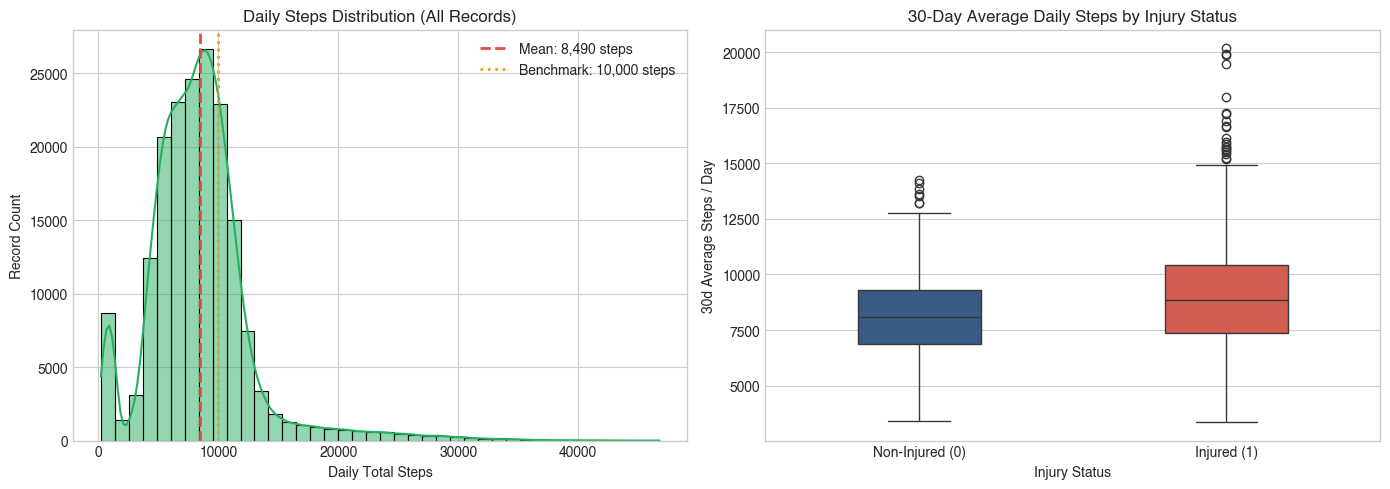

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Steps Distribution across all daily records
sns.histplot(act_df['TotalSteps'], bins=40, kde=True, color='#27ae60', ax=axes[0], edgecolor='black')
axes[0].axvline(act_df['TotalSteps'].mean(), color='#e74c3c', linestyle='--', linewidth=2,
                label=f"Mean: {act_df['TotalSteps'].mean():,.0f} steps")
axes[0].axvline(10000, color='#f39c12', linestyle=':', linewidth=2, label='Benchmark: 10,000 steps')
axes[0].set_title('Daily Steps Distribution (All Records)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Total Steps', fontsize=10)
axes[0].set_ylabel('Record Count', fontsize=10)
axes[0].legend()

# 2. Athlete 30-Day Avg Steps by Injury Status
if feats_df is not None:
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='avg_steps_30d',
                palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('30-Day Average Daily Steps by Injury Status', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Injury Status', fontsize=10)
    axes[1].set_ylabel('30d Average Steps / Day', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Pre-Injury Step Surges (7d vs 30d Steps Change)

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2531/817059507.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='steps_change_7d_vs_30d',
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2531/817059507.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


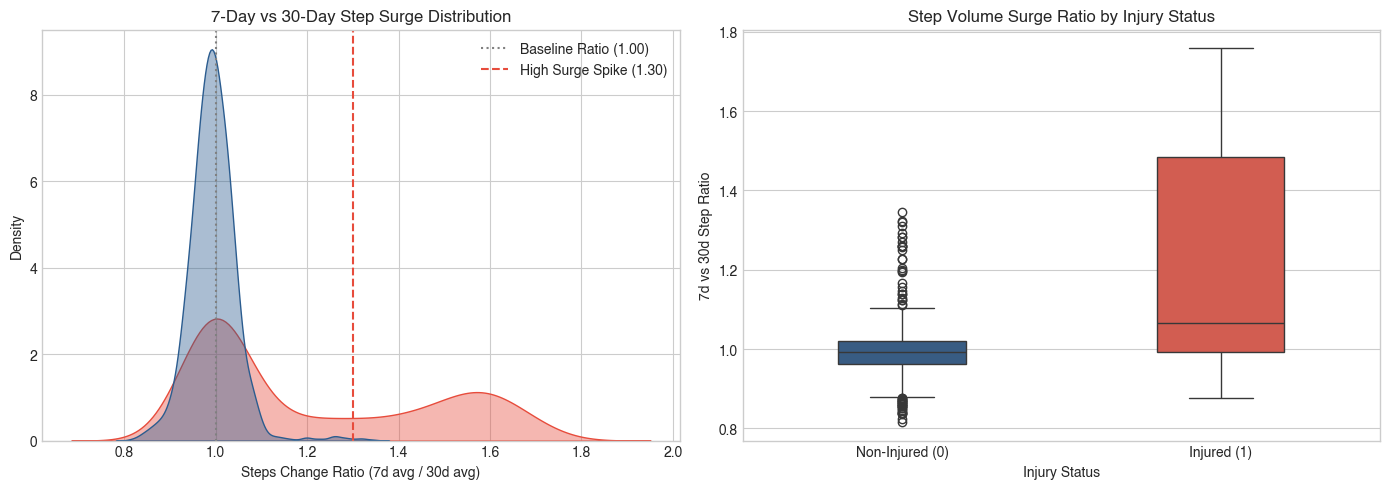

In [4]:
if feats_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Steps Change Ratio Distribution
    sns.kdeplot(data=feats_df, x='steps_change_7d_vs_30d', hue='injured_in_risk_window',
                fill=True, common_norm=False, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], alpha=0.4)
    axes[0].axvline(1.0, color='gray', linestyle=':', label='Baseline Ratio (1.00)')
    axes[0].axvline(1.3, color='#e74c3c', linestyle='--', label='High Surge Spike (1.30)')
    axes[0].set_title('7-Day vs 30-Day Step Surge Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Steps Change Ratio (7d avg / 30d avg)', fontsize=10)
    axes[0].legend()
    
    # 2. Steps Change Boxplot
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='steps_change_7d_vs_30d',
                palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('Step Volume Surge Ratio by Injury Status', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Injury Status', fontsize=10)
    axes[1].set_ylabel('7d vs 30d Step Ratio', fontsize=10)
    
    plt.tight_layout()
    plt.show()

---
## 💡 Key Analytical Insight

> **Insight**: While chronic step baselines remain within typical athletic ranges (~8,000–9,000 steps/day), athletes who sustained injuries experienced **acute +48.5% step surges** in their final 7 observation days (75th percentile of 1.485 vs 1.021 for non-injured peers), indicating that sudden increases in movement volume without gradual conditioning are strong triggers of injury.
